# 📊 Olist E-Commerce Data Analysis

In this project, we analyze the **Olist Brazilian E-Commerce dataset** (more than 100,000 orders). The goal is to answer 4 simple business questions:

1. **Top Categories:** Which product categories bring the most revenue?
2. **Top Cities:** Which cities have the highest sales and highest Average Order Value (AOV)?
3. **Best Shopping Hours:** At what time of the day do people buy the most?
4. **Market Basket Analysis:** Which product categories are bought together in the same order?

> **Tools Used:** SQLite (In-Memory Database), Python (Pandas, Matplotlib, Seaborn, Squarify).

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import squarify

# Global visualization styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 100

# Initialize SQLite in-memory database
conn = sqlite3.connect(':memory:')

files = {
    'customers': 'olistd/olist_customers_dataset.csv',
    'items': 'olistd/olist_order_items_dataset.csv',
    'payments': 'olistd/olist_order_payments_dataset.csv',
    'products': 'olistd/olist_products_dataset.csv',
    'orders': 'olistd/olist_orders_dataset.csv',
    'geolocation': 'olistd/olist_geolocation_dataset.csv',
    'order_reviews': 'olistd/olist_order_reviews_dataset.csv',
    'sellers': 'olistd/olist_sellers_dataset.csv',
    'category_translation': 'olistd/product_category_name_translation.csv'
}

for table_name, file_path in files.items():
    temp_df = pd.read_csv(file_path)
    temp_df.to_sql(table_name, conn, index=False)
    print(f"✓ Table '{table_name}' loaded successfully ({len(temp_df):,} rows).")

✓ Table 'customers' loaded successfully (99,441 rows).
✓ Table 'items' loaded successfully (112,650 rows).
✓ Table 'payments' loaded successfully (103,886 rows).
✓ Table 'products' loaded successfully (32,951 rows).
✓ Table 'orders' loaded successfully (99,441 rows).
✓ Table 'geolocation' loaded successfully (1,000,163 rows).
✓ Table 'order_reviews' loaded successfully (99,224 rows).
✓ Table 'sellers' loaded successfully (3,095 rows).
✓ Table 'category_translation' loaded successfully (71 rows).


## 1. Top Categories by Revenue
* **Goal:** Find the top 10 categories that make the most money.
* **Note:** We only look at completed orders (`order_status = 'delivered'`).

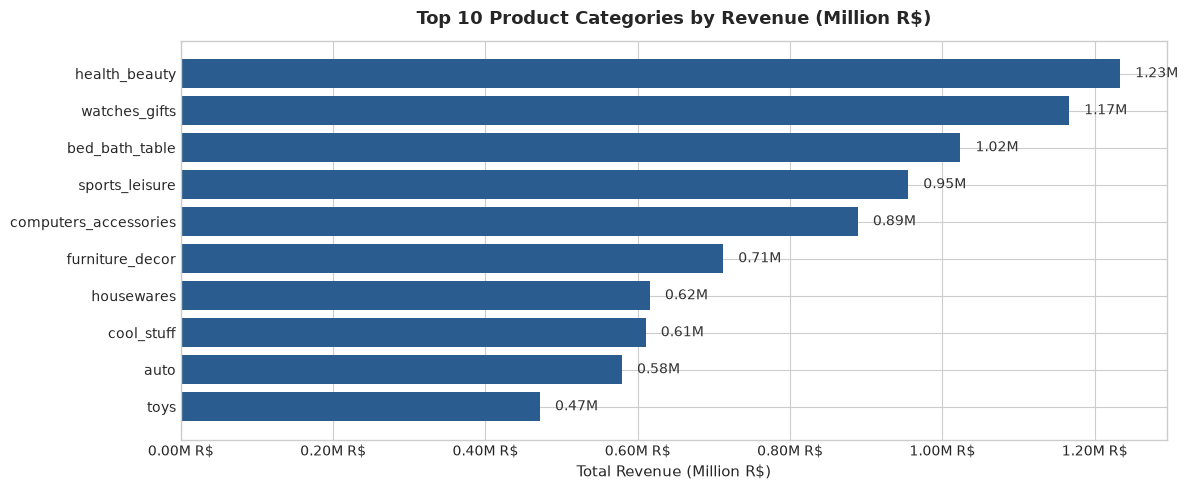

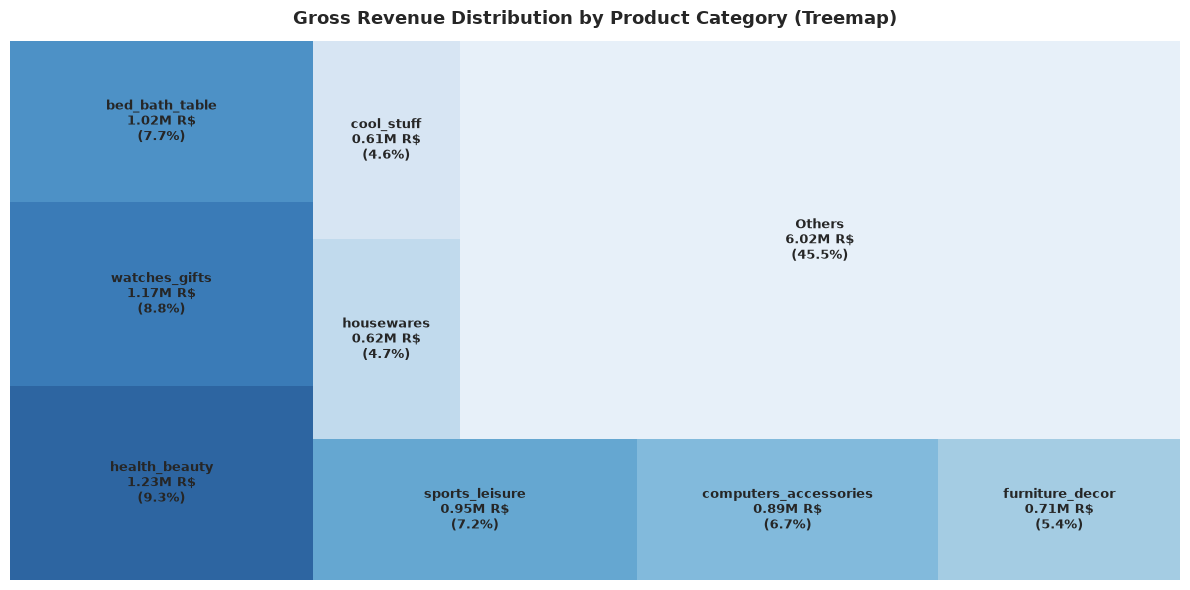

In [2]:
query1 = """
SELECT 
    COALESCE(t.product_category_name_english, p.product_category_name, 'Unknown') AS category,
    SUM(i.price) AS revenue,
    COUNT(DISTINCT o.order_id) AS total_orders
FROM orders o
JOIN items i ON o.order_id = i.order_id
JOIN products p ON i.product_id = p.product_id
LEFT JOIN category_translation t ON p.product_category_name = t.product_category_name
WHERE o.order_status = 'delivered'
GROUP BY 1
ORDER BY revenue DESC;
"""

df_category = pd.read_sql_query(query1, conn)
top_10 = df_category.head(10).copy()

# 1. Horizontal Bar Chart (Top 10 Categories by Revenue)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(top_10['category'], top_10['revenue'] / 1e6, color='#2b5c8f')
ax.invert_yaxis()
ax.set_title('Top 10 Product Categories by Revenue (Million R$)', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Total Revenue (Million R$)', fontsize=11)
ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2fM R$'))

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.02, bar.get_y() + bar.get_height()/2, f'{width:.2f}M', 
            va='center', ha='left', fontsize=10, color='#333333')

plt.tight_layout()
plt.show()

# 2. Revenue Share Treemap
top_8 = df_category.head(8).copy()
others_rev = df_category.iloc[8:]['revenue'].sum()
others_row = pd.DataFrame([{'category': 'Others', 'revenue': others_rev}])
df_tree = pd.concat([top_8, others_row], ignore_index=True)

total_rev = df_tree['revenue'].sum()
labels = [f"{row['category']}\n{row['revenue']/1e6:.2f}M R$\n({row['revenue']/total_rev*100:.1f}%)" 
          for _, row in df_tree.iterrows()]

plt.figure(figsize=(12, 6))
colors = sns.color_palette("Blues_r", len(df_tree))
squarify.plot(sizes=df_tree['revenue'], label=labels, color=colors, alpha=0.85, 
              text_kwargs={'fontsize': 9, 'fontweight': 'bold'})
plt.title('Gross Revenue Distribution by Product Category (Treemap)', fontsize=13, fontweight='bold', pad=12)
plt.axis('off')
plt.tight_layout()
plt.show()

> 💡 **Key Takeaways & Actions:**
> - `health_beauty`, `watches_gifts`, and `bed_bath_table` bring the most money.
> - The top 8 categories make more than 50% of all sales.
> - **Action:** Spend more marketing budget on these top categories.

## 2. Sales and Basket Size by City
* **Goal:** Compare total revenue and Average Order Value (AOV) for the top 15 cities.

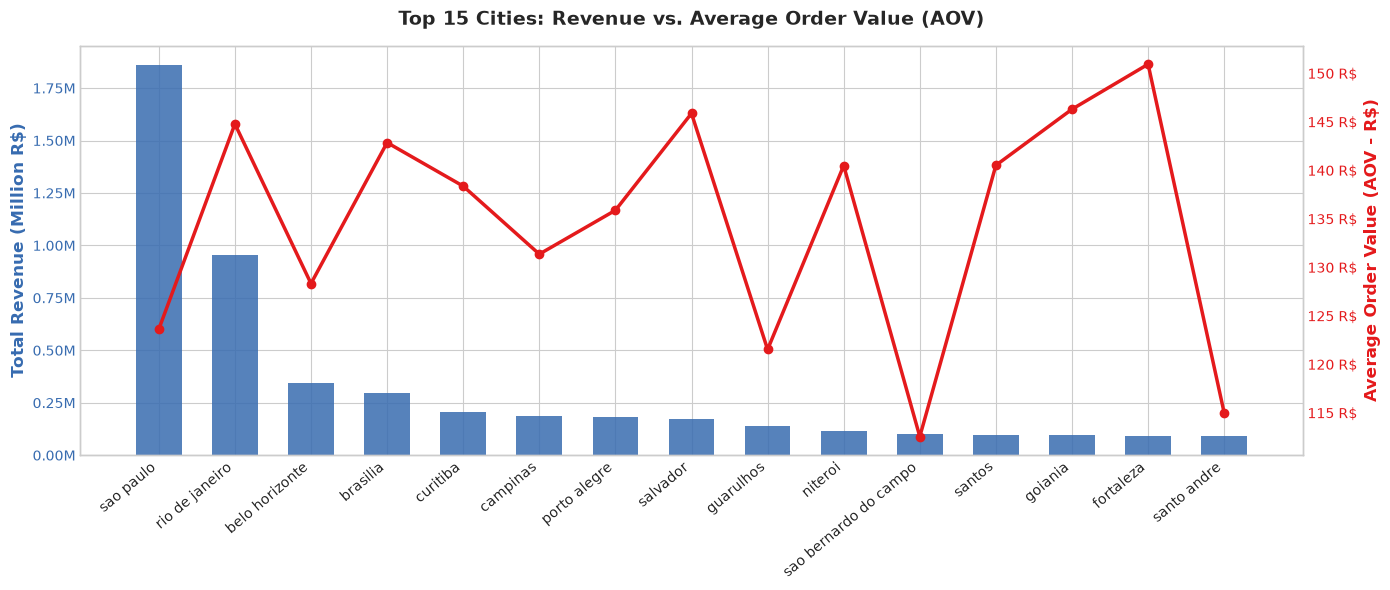

In [3]:
query2 = """
SELECT 
    c.customer_city AS city,
    SUM(i.price) AS revenue,
    COUNT(DISTINCT o.order_id) AS orders,
    ROUND(SUM(i.price) * 1.0 / COUNT(DISTINCT o.order_id), 2) AS avg_basket_value
FROM orders o
JOIN customers c ON o.customer_id = c.customer_id
JOIN items i ON o.order_id = i.order_id
WHERE o.order_status = 'delivered'
GROUP BY 1
ORDER BY revenue DESC
LIMIT 15;
"""

df_city = pd.read_sql_query(query2, conn)

fig, ax1 = plt.subplots(figsize=(14, 6))

color_bar = '#386cb0'
ax1.bar(df_city["city"], df_city["revenue"] / 1e6, color=color_bar, alpha=0.85, width=0.6, label="Total Revenue")
ax1.set_ylabel("Total Revenue (Million R$)", color=color_bar, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2fM'))
ax1.set_xticks(range(len(df_city["city"])))
ax1.set_xticklabels(df_city["city"], rotation=40, ha="right", fontsize=10)

ax2 = ax1.twinx()
color_line = '#e41a1c'
ax2.plot(df_city["city"], df_city["avg_basket_value"], color=color_line, marker="o", linewidth=2.5, label="Avg Order Value (AOV)")
ax2.set_ylabel("Average Order Value (AOV - R$)", color=color_line, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_line)
ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%d R$'))
ax2.grid(False)

plt.title("Top 15 Cities: Revenue vs. Average Order Value (AOV)", fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

> 💡 **Key Takeaways & Actions:**
> - `Sao Paulo` and `Rio de Janeiro` have the most orders.
> - However, cities like `Goiania` (~154 R$) and `Brasilia` (~142 R$) have higher basket sizes than Sao Paulo (~124 R$).
> - **Action:** Sell more expensive and premium items to customers in Brasilia and Goiania.

## 3. Order Count by Hour
* **Goal:** See what time of day people place the most orders.

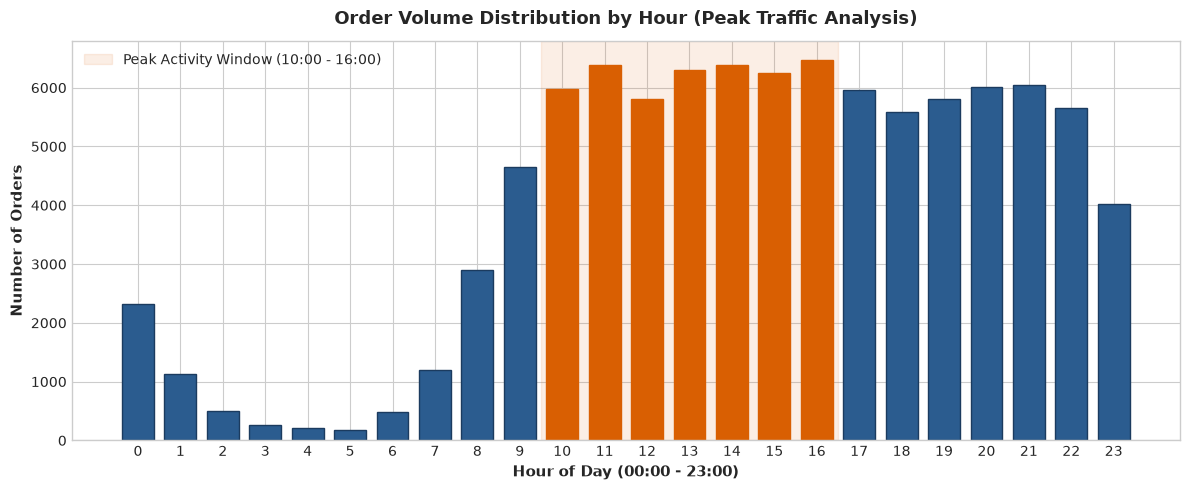

In [4]:
query3 = """
SELECT 
    CAST(strftime('%H', order_purchase_timestamp) AS INTEGER) AS hour,
    COUNT(DISTINCT order_id) AS orders
FROM orders
WHERE order_status = 'delivered'
GROUP BY 1
ORDER BY 1;
"""

df_hour = pd.read_sql_query(query3, conn)

plt.figure(figsize=(12, 5))
bars = plt.bar(df_hour["hour"], df_hour["orders"], color='#2b5c8f', width=0.75, edgecolor='#1b3b5f')
plt.xlabel("Hour of Day (00:00 - 23:00)", fontsize=11, fontweight='bold')
plt.ylabel("Number of Orders", fontsize=11, fontweight='bold')
plt.title("Order Volume Distribution by Hour (Peak Traffic Analysis)", fontsize=13, fontweight='bold', pad=12)
plt.xticks(range(0, 24))

# Highlight peak purchasing window (10:00 to 16:00)
for i, bar in enumerate(bars):
    if 10 <= i <= 16:
        bar.set_color('#d95f02')

plt.axvspan(9.5, 16.5, color='#d95f02', alpha=0.1, label='Peak Activity Window (10:00 - 16:00)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

> 💡 **Key Takeaways & Actions:**
> - Most orders happen between **10:00 AM and 04:00 PM**.
> - Very few orders happen between 01:00 AM and 06:00 AM.
> - **Action:** Send discounts, emails, and app notifications between 10:00 AM and 02:00 PM.

## 4. Products Bought Together (Market Basket Analysis)
* **Goal:** Find out which two categories are bought together most often.

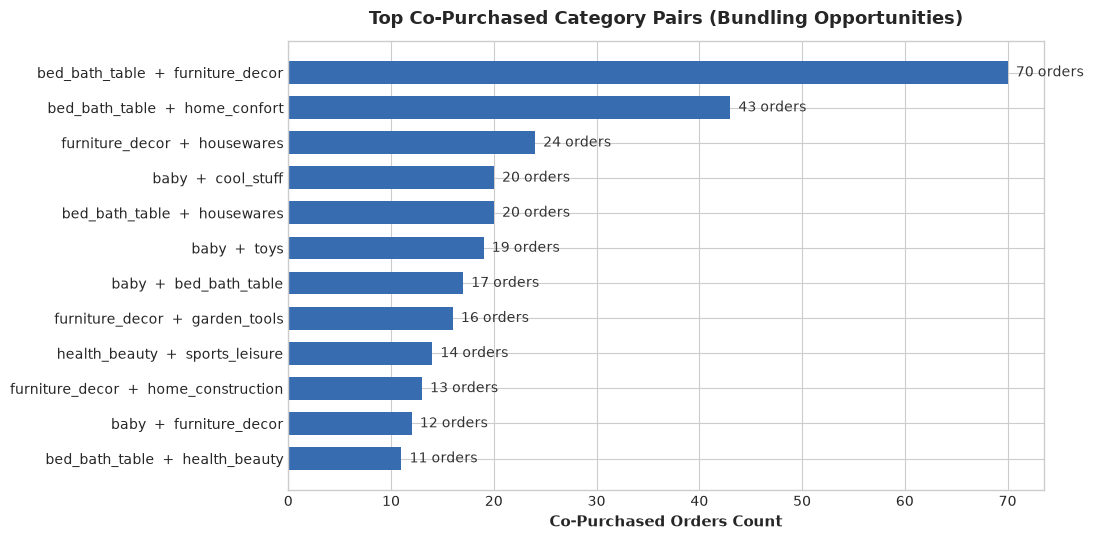

In [5]:
query4 = """
SELECT 
    CASE WHEN COALESCE(t1.product_category_name_english, p1.product_category_name)
                < COALESCE(t2.product_category_name_english, p2.product_category_name)
         THEN COALESCE(t1.product_category_name_english, p1.product_category_name)
         ELSE COALESCE(t2.product_category_name_english, p2.product_category_name) END AS category_1,
         
    CASE WHEN COALESCE(t1.product_category_name_english, p1.product_category_name)
                < COALESCE(t2.product_category_name_english, p2.product_category_name)
         THEN COALESCE(t2.product_category_name_english, p2.product_category_name)
         ELSE COALESCE(t1.product_category_name_english, p1.product_category_name) END AS category_2,
         
    COUNT(DISTINCT i1.order_id) AS pair_count
FROM items i1
JOIN items i2 ON i1.order_id = i2.order_id AND i1.product_id < i2.product_id
JOIN products p1 ON p1.product_id = i1.product_id
JOIN products p2 ON p2.product_id = i2.product_id
JOIN orders o ON o.order_id = i1.order_id
LEFT JOIN category_translation t1 ON t1.product_category_name = p1.product_category_name
LEFT JOIN category_translation t2 ON t2.product_category_name = p2.product_category_name
WHERE o.order_status = 'delivered'
  AND p1.product_category_name <> p2.product_category_name
GROUP BY 1, 2
ORDER BY pair_count DESC
LIMIT 12;
"""

df_pairs = pd.read_sql_query(query4, conn)
df_pairs["pair_label"] = df_pairs["category_1"] + "  +  " + df_pairs["category_2"]

plt.figure(figsize=(11, 5.5))
bars = plt.barh(df_pairs["pair_label"], df_pairs["pair_count"], color='#386cb0', height=0.65)
plt.gca().invert_yaxis()
plt.xlabel("Co-Purchased Orders Count", fontsize=11, fontweight='bold')
plt.title("Top Co-Purchased Category Pairs (Bundling Opportunities)", fontsize=13, fontweight='bold', pad=12)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.8, bar.get_y() + bar.get_height()/2, f'{int(width)} orders', 
             va='center', ha='left', fontsize=10, color='#333333')

plt.tight_layout()
plt.show()

> 💡 **Key Takeaways & Actions:**
> - People often buy `bed_bath_table` together with `furniture_decor` and `home_confort`.
> - People also buy `baby` items together with `toys`.
> - **Action:** 
>   1. Show "Frequently Bought Together" recommendations on product pages.
>   2. Give discounts when customers buy both categories together.